<a href="https://colab.research.google.com/github/Mazinpotrick/Walmart_sales_Analysis-and-Prediction/blob/main/walmart_Sales_Analysis_and_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


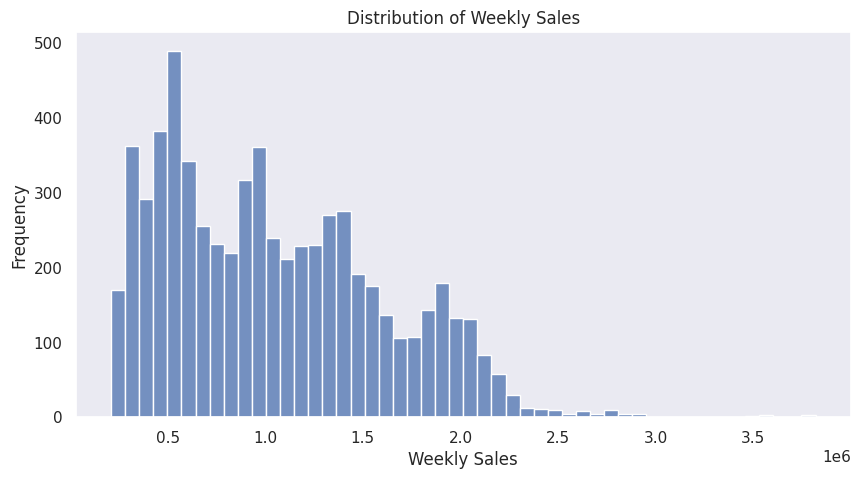

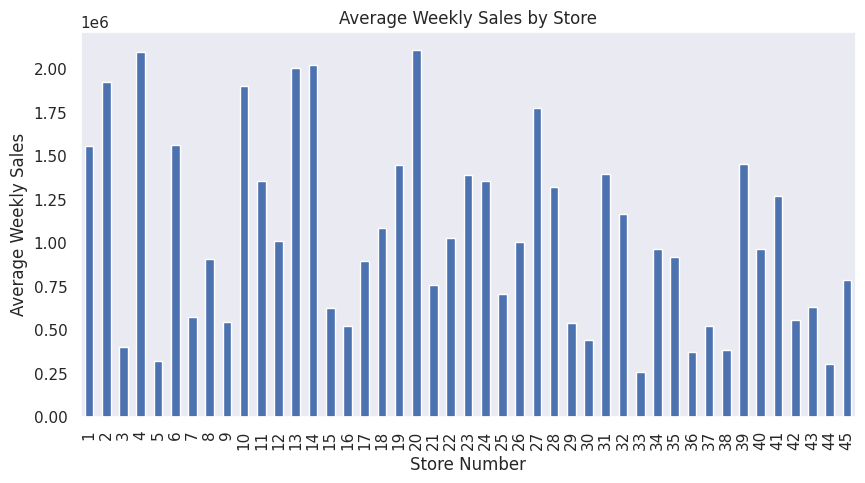

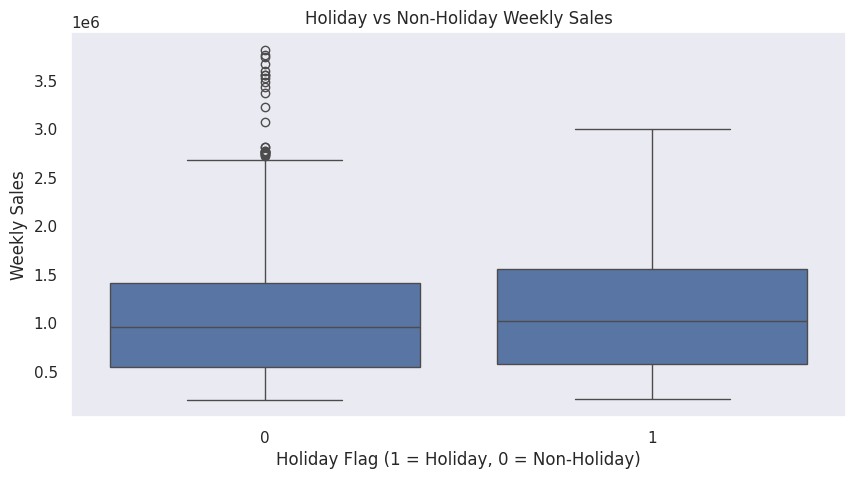

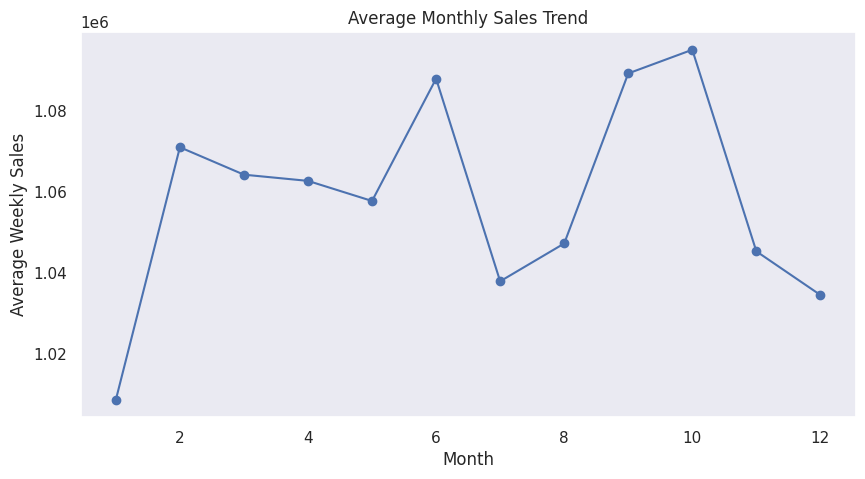

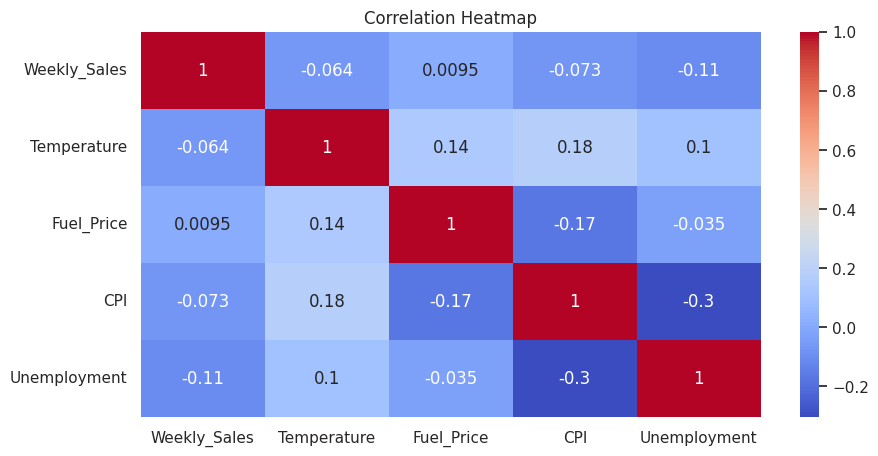

Model Performance Results:
Mean Absolute Error (MAE): 433274.8811147915
Mean Squared Error (MSE): 274455221280.6605
Root Mean Squared Error (RMSE): 523884.7404541007
R2 Score: 0.148063534059508


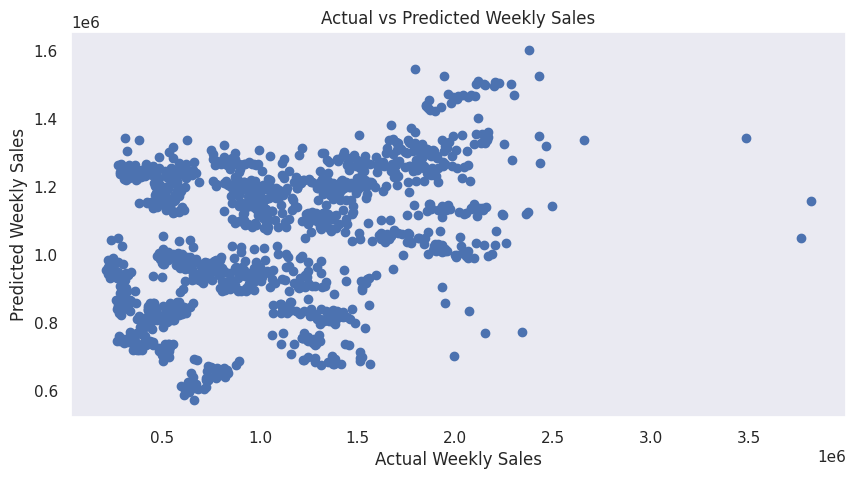


Business Insights:
1. Holiday weeks have noticeably higher sales.
2. Sales performance varies significantly between stores.
3. CPI and Unemployment show influence on weekly sales.
4. Linear Regression provides a reasonable baseline forecast.
5. These insights can help Walmart in inventory and workforce planning.



In [3]:
# STEP 1: import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Improve graph appearance

plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="dark")



# STEP 2: Load the dataset

# Upload Walmart_Sales.csv
# Then read the file using pandas

df = pd.read_csv("Walmart_Sales.csv")

# Display first 5 rows to understand data structure
df.head()


# STEP 3: Understand the dataset

# info() shows column names, data types, and missing values
df.info()

# describe() gives statistical summary of numeric columns
df.describe()


# STEP 4: Data Cleaning & Feature Engineering


# Convert Date column from text to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Check if any missing values exist
df.isnull().sum()

# Extract useful features from Date column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

# Verify changes
df.head()



# STEP 5: Exploratory Data Analysis (EDA)

#  Distribution of Weekly Sales
plt.figure()
sns.histplot(df['Weekly_Sales'], bins=50)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()


#  Average Weekly Sales by Store
store_sales = df.groupby('Store')['Weekly_Sales'].mean()

plt.figure()
store_sales.plot(kind='bar')
plt.title("Average Weekly Sales by Store")
plt.xlabel("Store Number")
plt.ylabel("Average Weekly Sales")
plt.show()


# Holiday vs Non-Holiday Sales Comparison
plt.figure()
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)
plt.title("Holiday vs Non-Holiday Weekly Sales")
plt.xlabel("Holiday Flag (1 = Holiday, 0 = Non-Holiday)")
plt.ylabel("Weekly Sales")
plt.show()


# Monthly Sales Trend
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure()
monthly_sales.plot(marker='o')
plt.title("Average Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()



# This shows relationship between sales and economic factors
plt.figure()
sns.heatmap(
    df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()



# STEP 6: Select Features for Machine Learning Model


# Independent variables (inputs)
features = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment'
]

X = df[features]

# Target variable (output)
y = df['Weekly_Sales']



# STEP 7: Split data into Training & Testing sets

# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



# STEP 8: Train the Machine Learning Model

# Using Linear Regression for sales forecasting

model = LinearRegression()
model.fit(X_train, y_train)


# STEP 9: Make Predictions

# Predict weekly sales on test data

y_pred = model.predict(X_test)


# STEP 10: Evaluate Model Performance


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance Results:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)



# STEP 11: Actual vs Predicted Sales Visualization


plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")
plt.show()


# STEP 12: Final Business Insights

print("""
Business Insights:
1. Holiday weeks have noticeably higher sales.
2. Sales performance varies significantly between stores.
3. CPI and Unemployment show influence on weekly sales.
4. Linear Regression provides a reasonable baseline forecast.
5. These insights can help Walmart in inventory and workforce planning.
""")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')